In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 1000

df = pd.DataFrame({
    'customer_id': range(1, n+1),
    'age': np.random.randint(18, 65, n),
    'gender': np.random.choice(['Male', 'Female'], n),
    'channel': np.random.choice(['Email', 'Social Media', 'SEO', 'Paid Ads', 'Referral'], n, p=[0.3, 0.25, 0.2, 0.15, 0.1]),
    'campaign': np.random.choice(['Campaign A', 'Campaign B', 'Campaign C'], n),
    'impressions': np.random.randint(100, 10000, n),
    'clicks': np.random.randint(10, 500, n),
    'conversions': np.random.randint(0, 50, n),
    'spend': np.round(np.random.uniform(10, 500, n), 2),
    'revenue': np.round(np.random.uniform(0, 1000, n), 2),
    'region': np.random.choice(['North', 'South', 'East', 'West'], n)
})

df['ROI'] = np.round((df['revenue'] - df['spend']) / df['spend'] * 100, 2)
df.to_csv('marketing_campaign.csv', index=False)
print("Dataset created!")
print(df.shape)
df.head()

Dataset created!
(1000, 12)


,customer_id,age,gender,channel,campaign,impressions,clicks,conversions,spend,revenue,region,ROI
0,1,56,Male,SEO,Campaign C,4657,92,12,164.89,718.70,North,335.87
1,2,46,Female,Social Media,Campaign B,2279,195,24,37.31,586.24,North,1471.27
2,3,32,Female,Email,Campaign A,9165,261,3,308.81,492.37,East,59.44
3,4,60,Female,Referral,Campaign C,8375,364,10,127.99,192.32,North,50.26
4,5,25,Male,Social Media,Campaign B,1522,247,31,199.54,463.94,South,132.50


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Basic Info
print("Dataset Info:")
print(df.isnull().sum())
print("\nBasic Stats:")
print(df.describe())

Dataset Info:
customer_id    0
age            0
gender         0
channel        0
campaign       0
impressions    0
clicks         0
conversions    0
spend          0
revenue        0
region         0
ROI            0
dtype: int64

Basic Stats:
       customer_id          age  impressions       clicks  conversions  \
count  1000.000000  1000.000000  1000.000000  1000.000000  1000.000000   
mean    500.500000    40.986000  4838.401000   264.676000    24.628000   
std     288.819436    13.497852  2821.381573   140.306361    14.240098   
min       1.000000    18.000000   102.000000    11.000000     0.000000   
25%     250.750000    29.000000  2555.750000   147.750000    13.000000   
50%     500.500000    42.000000  4641.500000   272.000000    24.000000   
75%     750.250000    52.000000  7279.750000   387.000000    37.000000   
max    1000.000000    64.000000  9997.000000   499.000000    49.000000   

             spend      revenue          ROI  
count  1000.000000  1000.000000  1000.000

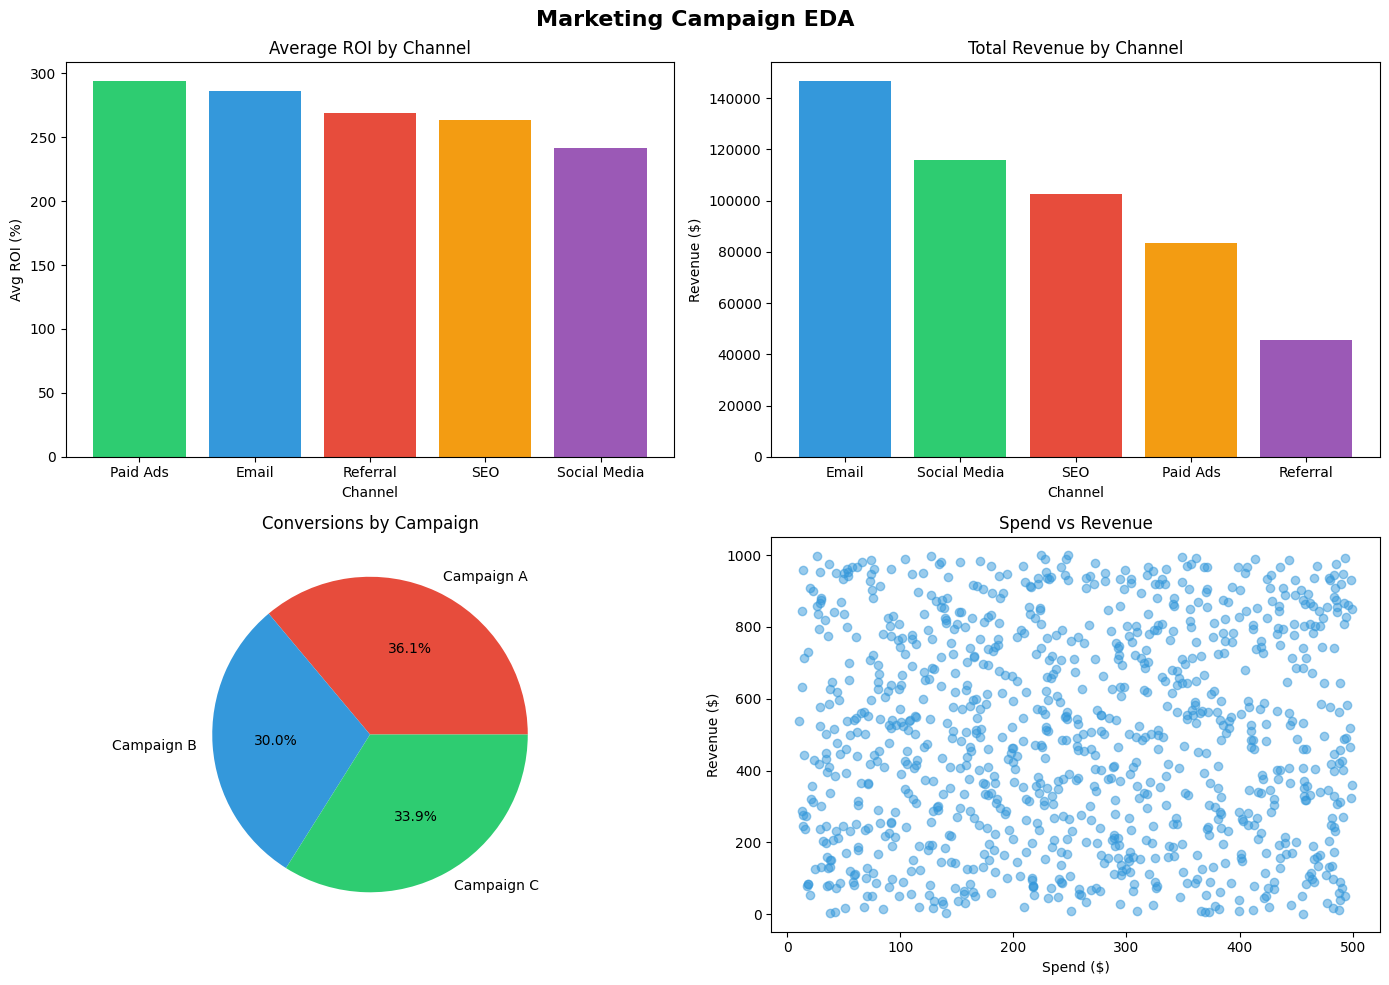

Charts saved!


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Marketing Campaign EDA', fontsize=16, fontweight='bold')

# 1. ROI by Channel
channel_roi = df.groupby('channel')['ROI'].mean().sort_values(ascending=False)
axes[0,0].bar(channel_roi.index, channel_roi.values, color=['#2ecc71','#3498db','#e74c3c','#f39c12','#9b59b6'])
axes[0,0].set_title('Average ROI by Channel')
axes[0,0].set_xlabel('Channel')
axes[0,0].set_ylabel('Avg ROI (%)')

# 2. Revenue by Channel
channel_rev = df.groupby('channel')['revenue'].sum().sort_values(ascending=False)
axes[0,1].bar(channel_rev.index, channel_rev.values, color=['#3498db','#2ecc71','#e74c3c','#f39c12','#9b59b6'])
axes[0,1].set_title('Total Revenue by Channel')
axes[0,1].set_xlabel('Channel')
axes[0,1].set_ylabel('Revenue ($)')

# 3. Conversions by Campaign
camp_conv = df.groupby('campaign')['conversions'].sum()
axes[1,0].pie(camp_conv.values, labels=camp_conv.index, autopct='%1.1f%%', colors=['#e74c3c','#3498db','#2ecc71'])
axes[1,0].set_title('Conversions by Campaign')

# 4. Spend vs Revenue
axes[1,1].scatter(df['spend'], df['revenue'], alpha=0.5, color='#3498db')
axes[1,1].set_title('Spend vs Revenue')
axes[1,1].set_xlabel('Spend ($)')
axes[1,1].set_ylabel('Revenue ($)')

plt.tight_layout()
plt.savefig('eda_charts.png', dpi=150)
plt.show()
print("Charts saved!")

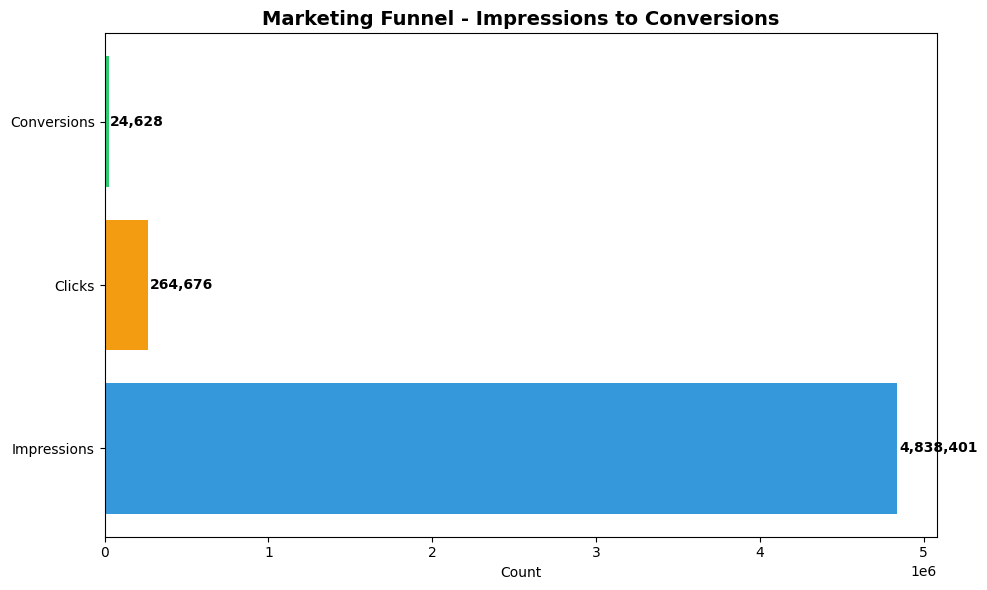

Funnel chart saved!


In [4]:
# Marketing Funnel
funnel_data = {
    'Stage': ['Impressions', 'Clicks', 'Conversions'],
    'Count': [df['impressions'].sum(), df['clicks'].sum(), df['conversions'].sum()]
}

funnel_df = pd.DataFrame(funnel_data)

plt.figure(figsize=(10, 6))
colors = ['#3498db', '#f39c12', '#2ecc71']
bars = plt.barh(funnel_df['Stage'], funnel_df['Count'], color=colors)
plt.title('Marketing Funnel - Impressions to Conversions', fontsize=14, fontweight='bold')
plt.xlabel('Count')

for bar, val in zip(bars, funnel_df['Count']):
    plt.text(bar.get_width() + 10000, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('funnel_chart.png', dpi=150)
plt.show()
print("Funnel chart saved!")

In [5]:
# Summary Report
channel_roi = df.groupby('channel')['ROI'].mean().sort_values(ascending=False)
channel_rev = df.groupby('channel')['revenue'].sum().sort_values(ascending=False)
channel_spend = df.groupby('channel')['spend'].sum()

best_roi = channel_roi.index[0]
best_rev = channel_rev.index[0]
worst_roi = channel_roi.index[-1]

report = f"""
╔══════════════════════════════════════════════════════════╗
         MARKETING CAMPAIGN - BUSINESS INSIGHTS REPORT
              SkillCraft Technology Internship - Task 04
╚══════════════════════════════════════════════════════════╝

📊 DATASET OVERVIEW
- Total Customers    : {len(df):,}
- Total Spend        : ${df['spend'].sum():,.2f}
- Total Revenue      : ${df['revenue'].sum():,.2f}
- Overall Avg ROI    : {df['ROI'].mean():.2f}%

📈 ROI BY CHANNEL
{channel_roi.to_string()}

💰 REVENUE BY CHANNEL
{channel_rev.to_string()}

🔍 KEY INSIGHTS
1. Best ROI Channel    : {best_roi} ({channel_roi[best_roi]:.2f}%)
2. Best Revenue Channel: {best_rev} (${channel_rev[best_rev]:,.2f})
3. Worst ROI Channel   : {worst_roi} ({channel_roi[worst_roi]:.2f}%)

✅ RECOMMENDATIONS
1. Increase budget for {best_roi} — highest ROI!
2. {best_rev} generates maximum revenue — scale up!
3. Reduce spend on {worst_roi} — lowest ROI performer
4. Focus on conversion optimization across all channels

👩‍💻 Prepared by: Ashwini Vindravath
   SkillCraft Technology Data Analytics Internship
"""

print(report)

# Save report
with open('business_insights_report.txt', 'w') as f:
    f.write(report)
print("Report saved!")


╔══════════════════════════════════════════════════════════╗
         MARKETING CAMPAIGN - BUSINESS INSIGHTS REPORT
              SkillCraft Technology Internship - Task 04
╚══════════════════════════════════════════════════════════╝

📊 DATASET OVERVIEW
- Total Customers    : 1,000
- Total Spend        : $255,010.00
- Total Revenue      : $494,487.28
- Overall Avg ROI    : 270.20%

📈 ROI BY CHANNEL
channel
Paid Ads        294.030323
Email           286.548754
Referral        269.027826
SEO             263.674348
Social Media    241.739317

💰 REVENUE BY CHANNEL  
channel
Email           146678.47
Social Media    115913.82
SEO             102644.84
Paid Ads         83575.23
Referral         45674.92

🔍 KEY INSIGHTS
1. Best ROI Channel    : Paid Ads (294.03%)
2. Best Revenue Channel: Email ($146,678.47)
3. Worst ROI Channel   : Social Media (241.74%)

✅ RECOMMENDATIONS
1. Increase budget for Paid Ads — highest ROI!
2. Email generates maximum revenue — scale up!
3. Reduce spend on Social 